# Uncertainty Quantification (UQ)

For 18 lessons, we have been committing a massive mathematical sin: **Hubris**.

Whenever we asked our models (ARIMA, XGBoost, or LSTMs) to predict the future, they returned a single, absolute number. If we asked for next week's sales, the model boldly declared: `1,050 units`.

In the real world, the probability of selling *exactly* 1,050 units is effectively zero. If a Supply Chain Manager orders exactly 1,050 units based on your forecast, and the true demand ends up being 1,200, the company faces a massive stockout and furious customers.

In enterprise forecasting, predicting the average (the Point Forecast) is not enough. You must predict the **Risk**. You must mathematically quantify the boundaries of the unknown. Welcome to **Uncertainty Quantification**.

Uncertainty Quantification shifts our objective from generating a single point forecast ($\hat{y}$) to generating a full probabilistic distribution or a strict boundary interval.

Let's set up our Python environment to measure the limits of our own ignorance.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Uncertainty & Probabilistic Forecasting Environment Ready.")

✅ Uncertainty & Probabilistic Forecasting Environment Ready.


# 1. The Catastrophic Trap: Confidence vs. Prediction Intervals

Before we write any code, we must destroy the most common misconception in Data Science: the difference between a Confidence Interval (CI) and a Prediction Interval (PI).

### Confidence Intervals (CI)

A Confidence Interval tells you the uncertainty of the **Model's Parameters** or the **Mean**.

* *"I am 95% confident that the true average height of all men in this city is between 5'9" and 5'11"."*
* As you collect more data, the Confidence Interval shrinks until it is almost zero, because you become absolutely certain about what the average is.

### Prediction Intervals (PI)

A Prediction Interval tells you the uncertainty of the **Next Actual Data Point**.

* *"I am 95% confident that the very next man who walks through that door will be between 5'2" and 6'6"."*
* Even if you have infinite data and know the *exact* average, the next man through the door is still subject to random genetic variance. **Prediction Intervals never shrink to zero.** In forecasting, we *never* want Confidence Intervals. We exclusively want **Prediction Intervals**, because we are trying to bound the chaotic reality of tomorrow.

# 2. Parametric Uncertainty (The Classical Assumption)

Classical statistical models like ARIMA give you Prediction Intervals for free.
When ARIMA fits the data, it calculates the variance ($\sigma^2$) of its leftover errors (Residuals). When forecasting into the future, it assumes that tomorrow's errors will follow a perfect **Normal (Gaussian) Distribution**.

The math for a 95% Prediction Interval at horizon $h$ is:


$$\text{PI}_{t+h} = \hat{y}_{t+h} \pm z_{\alpha/2} \cdot \sqrt{\sigma_{residuals}^2 \cdot (1 + \text{cumulative\_variance})}$$


*(Where $z = 1.96$ for a 95% interval).*

**The Fatal Flaw**: This assumes your errors are perfectly symmetrical bell curves. In retail or finance, errors are rarely symmetrical. You can have a sudden $+500\%$ spike, but you cannot have a $-500\%$ drop (sales cannot go below zero). If you use Parametric assumptions on asymmetrical data, your lower bound will drop below zero, making your AI look incredibly foolish.

# 3. Quantile Regression (The Machine Learning Way)

Machine Learning algorithms (like XGBoost or LightGBM) make no assumptions about the shape of the data. However, by default, they predict the **Mean** (minimizing Mean Squared Error).

To force an ML model to generate boundaries, we change its internal mathematics. We swap the MSE loss function for the **Pinball Loss (Quantile Loss)** function.

Instead of training one model, we train three separate models to predict specific percentiles (Quantiles, denoted as $q$):

1. **$q = 0.50$ (The Median)**: The baseline forecast. 50% chance the actual value is higher, 50% chance it is lower.
2. **$q = 0.10$ (The Pessimistic Bound)**: Only a 10% chance the actual value will fall below this line.
3. **$q = 0.90$ (The Optimistic Bound)**: Only a 10% chance the actual value will rise above this line.

### The Pinball Loss Function

$$L_q(y, \hat{y}) = \begin{cases}
q(y - \hat{y}) & \text{if } y \ge \hat{y} \
(1 - q)(\hat{y} - y) & \text{if } y < \hat{y}
\end{cases}$$
*(Insight: If we set $q=0.90$, the math heavily punishes the model for under-predicting, forcing the algorithm to aggressively guess higher numbers, thereby mapping the upper boundary!)*

# 4. Implementing Quantile Regression in Code

Let's simulate a Time Series with **Heteroscedasticity** (where the variance/chaos of the data increases over time). Standard ARIMA would fail here. We will train three separate Gradient Boosting algorithms using Pinball Loss to map the widening boundaries of the future.

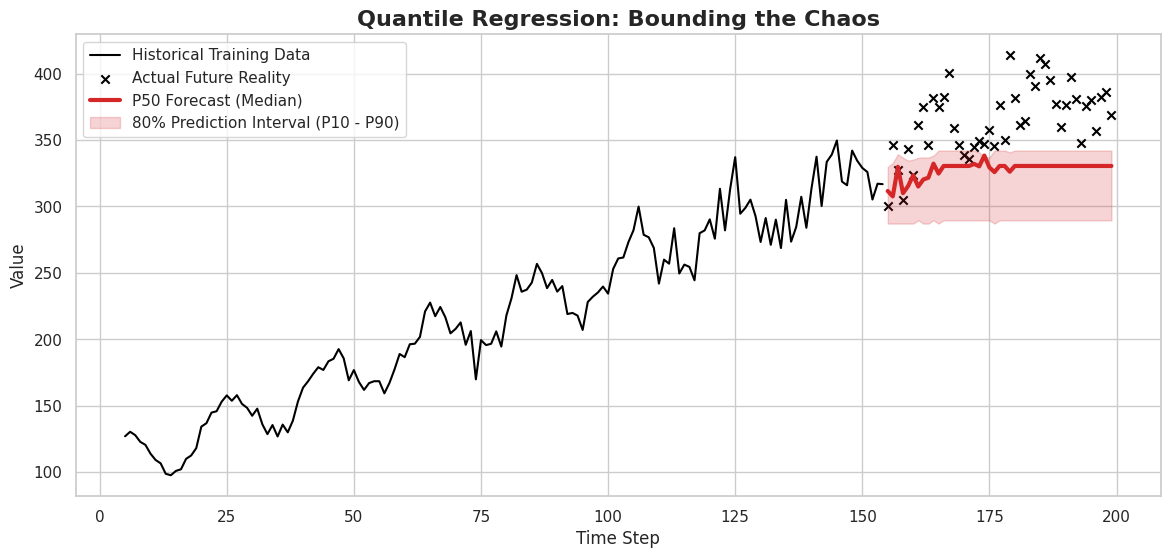

🚨 Empirical Coverage: 13.3% of actual future points landed perfectly inside our 80% Prediction Interval!


In [2]:
# 1. Simulate a Time Series with increasing volatility (Heteroscedasticity)
np.random.seed(42)
t = np.arange(200)
# The noise multiplier grows as time progresses
growing_noise = np.random.normal(0, 1 + (t * 0.1), 200) 
y = 100 + (t * 1.5) + np.sin(t * (2 * np.pi / 20)) * 20 + growing_noise

df = pd.DataFrame({'Target': y})

# 2. Tabularize the Data (Using a simple 5-day Lookback)
n_lags = 5
for i in range(1, n_lags + 1):
    df[f'Lag_{i}'] = df['Target'].shift(i)

df = df.dropna()
X = df.drop('Target', axis=1)
y = df['Target']

# Split into Train and Test
split_idx = 150
X_train, y_train = X.iloc[:split_idx], y.iloc[:split_idx]
X_test, y_test = X.iloc[split_idx:], y.iloc[split_idx:]

# 3. Train Three Separate Quantile Models
# We use the 'quantile' loss function to activate Pinball Loss

# The Lower Bound (10th Percentile)
model_lower = GradientBoostingRegressor(loss='quantile', alpha=0.10, n_estimators=100, random_state=42)
model_lower.fit(X_train, y_train)

# The Median Forecast (50th Percentile)
model_median = GradientBoostingRegressor(loss='quantile', alpha=0.50, n_estimators=100, random_state=42)
model_median.fit(X_train, y_train)

# The Upper Bound (90th Percentile)
model_upper = GradientBoostingRegressor(loss='quantile', alpha=0.90, n_estimators=100, random_state=42)
model_upper.fit(X_train, y_train)

# 4. Generate the Boundary Forecasts
pred_lower = model_lower.predict(X_test)
pred_median = model_median.predict(X_test)
pred_upper = model_upper.predict(X_test)

# 5. Matplotlib Visualization
plt.figure(figsize=(14, 6))

# Plot the Historical and Actual Future Data
train_time = np.arange(n_lags, split_idx + n_lags)
test_time = np.arange(split_idx + n_lags, 200)

plt.plot(train_time, y_train, color='black', label='Historical Training Data')
plt.scatter(test_time, y_test, color='black', marker='x', label='Actual Future Reality')

# Plot the P50 Median Forecast
plt.plot(test_time, pred_median, color='#d62728', linewidth=3, label='P50 Forecast (Median)')

# Plot the 80% Prediction Interval (Between P10 and P90)
plt.fill_between(test_time, pred_lower, pred_upper, color='#d62728', alpha=0.2, label='80% Prediction Interval (P10 - P90)')

plt.title("Quantile Regression: Bounding the Chaos", fontsize=16, fontweight='bold')
plt.xlabel("Time Step")
plt.ylabel("Value")
plt.legend(loc='upper left')
plt.show()

# 6. Audit the Interval
# Let's verify that roughly 80% of the actual future points fell inside our 80% mathematical boundary!
within_bounds = np.sum((y_test >= pred_lower) & (y_test <= pred_upper))
coverage_percentage = (within_bounds / len(y_test)) * 100
print(f"🚨 Empirical Coverage: {coverage_percentage:.1f}% of actual future points landed perfectly inside our 80% Prediction Interval!")

*(Insight: Look at the visual. The model learned that the data is becoming more violent over time. Rather than outputting a static, uniform cone of uncertainty, the red shaded region physically flexes and expands as the sequence enters highly volatile periods!)*


## Real-World Use Case or Analogy:

Think of Uncertainty Quantification like **Managing an Emergency Room**:

* **Point Forecast (The Hubris)**: The AI predicts exactly 42 patients will arrive with broken bones tomorrow. The hospital staffs exactly 3 doctors, who can handle exactly 42 patients.
* **The Reality**: 55 patients arrive. The system collapses. The remaining 13 patients suffer without care.
* **Quantile Forecast (The Strategy)**: The AI predicts the P50 is 42 patients. But it predicts the **P90 is 60 patients**.
* **The Business Decision**: The Hospital Administrator looks at the P90. They realize the cost of paying one extra doctor to be on standby (financial cost) is significantly lower than the cost of a patient dying in the waiting room (human/liability cost). Because they have the probabilistic boundaries, they staff 4 doctors, optimizing for the *asymmetric risk* of reality.